**Modelado Lineal Múltiple de la Concentración de PM2.5 en Monterrey: Evaluación de Factores Antropogénicos y Meteorológicos**
---
***
El presente estudio implementa un modelo de regresión lineal múltiple con el objetivo de analizar y predecir las concentraciones diarias de material particulado fino (PM2.5) en la Zona Metropolitana de Monterrey durante el periodo anual de 2025. Dada la alta toxicidad de este contaminante y su impacto crítico en la salud pública de una de las urbes industriales más activas de México.

Partiendo de la premisa de que los principales impulsores de la contaminación son la circulación vehicular y las emisiones del sector manufacturero, el modelo contrasta la influencia de estas fuentes antropogénicas frente a variables meteorológicas determinantes (velocidad del viento, temperatura promedio, precipitación y presión atmosférica), incorporando además la variación en la dinámica de movilidad durante los fines de semana. De este modo, el análisis no solo cuantifica el peso específico de cada componente en la variabilidad diaria del PM2.5 a lo largo de los 365 días de 2025, sino que también examina la capacidad y los límites de una formulación lineal para modelar la compleja atmósfera urbana de la región.

**Limpieza de Datos**
---
***
La preparación de los datos involucró un proceso de limpieza y unificación a partir de diversas fuentes oficiales (INEGI, SINAICA y Meteostat). Debido a que las variables de parque vehicular y actividad industrial estaban reportadas en escalas mensuales, se proyectaron de forma repetida a nivel diario para sincronizar una línea de tiempo uniforme de 365 días, asegurando un tamaño de muestra suficiente para controlar el sobreajuste (overfitting); no se tomaron en cuenta otros métodos por el poco cambio que tienen estas variables a través del tiempo. Asimismo, la serie de PM2.5 se transformó a partir de su estructura XML original para aislar el periodo 2025. Además, dentro de los valores meteorológicos existía una ausencia de datos de precipitación, los cuales fueron rellenados con 0 con base en el patrón que seguían los valores. La base final consolidó 10 predictores cuantitativos continuos junto con una variable indicadora (dummy) binaria que captura el impacto del cese de actividades durante los fines de semana.

In [ ]:
import pandas as pd
import numpy as np

df_crudo = pd.read_excel('VMRC_2.xlsx', header=None)
vehiculos_encontrados = df_crudo[df_crudo[0].notna()].head(3)
nombres = vehiculos_encontrados[0].tolist()
datos_mensuales = vehiculos_encontrados.iloc[:, 1:13].values
df_meses = pd.DataFrame(datos_mensuales.T, columns=['Automoviles', 'Camiones_Pasajeros', 'Camiones_Carga'])
df_meses['Mes_Num'] = range(1, 13)

fechas = pd.date_range(start='2025-01-01', end='2025-12-31')
df_diario = pd.DataFrame({'Fecha': fechas})
df_diario['Mes_Num'] = df_diario['Fecha'].dt.month


df_final = pd.merge(df_diario, df_meses, on='Mes_Num', how='left')
df_final = df_final.drop(columns=['Mes_Num'])

df_final.to_csv('VMRC_365_Dias.csv', index=False)

print(f"¡Éxito! Tu tabla pasó a tener {len(df_final)} filas y {len(df_final.columns)} columnas.")
df_final.head(36)

¡Éxito! Tu tabla pasó a tener 365 filas y 4 columnas.


,Fecha,Automoviles,Camiones_Pasajeros,Camiones_Carga
0,2025-01-01,39665439.0,506669.0,12073191.0
1,2025-01-02,39665439.0,506669.0,12073191.0
2,2025-01-03,39665439.0,506669.0,12073191.0
3,2025-01-04,39665439.0,506669.0,12073191.0
4,2025-01-05,39665439.0,506669.0,12073191.0
5,2025-01-06,39665439.0,506669.0,12073191.0
6,2025-01-07,39665439.0,506669.0,12073191.0
7,2025-01-08,39665439.0,506669.0,12073191.0
8,2025-01-09,39665439.0,506669.0,12073191.0
9,2025-01-10,39665439.0,506669.0,12073191.0


In [ ]:
import pandas as pd
import re

nombre_archivo = 'Datos SINAICA - San Pedro - PM2.5 - CH - 2025-01-01 - 2025-12-31.xls.csv'
with open(nombre_archivo, 'r', encoding='utf-8') as f:
    contenido = f.read()

datos_crudos = re.findall(r'<[^>]*Data[^>]*>(.*?)</[^>]*Data>', contenido, re.IGNORECASE)

registros = []
for i in range(0, len(datos_crudos), 5):
    if i + 3 < len(datos_crudos):
        parametro = datos_crudos[i].strip()
        fecha = datos_crudos[i+1].strip()
        concentracion = datos_crudos[i+3].strip()

        if parametro == 'PM2.5':
            try:
                valor_pm25 = float(concentracion)
                registros.append({'Fecha': fecha, 'PM2.5': valor_pm25})
            except ValueError:
                pass

df_horas = pd.DataFrame(registros)

df_diario = df_horas.groupby('Fecha', as_index=False)['PM2.5'].mean()

df_diario['PM2.5'] = df_diario['PM2.5'].round(2)
df_diario.to_csv('PM2.5_SanPedro_Diario_Limpio.csv', index=False)

print(f"¡Victoria! Rescatamos {len(df_horas)} horas de datos y las convertimos en {len(df_diario)} promedios diarios.")
df_diario.head(10)

¡Victoria! Rescatamos 6846 horas de datos y las convertimos en 365 promedios diarios.


,Fecha,PM2.5
0,2025-01-01,23.08
1,2025-01-02,30.62
2,2025-01-03,26.95
3,2025-01-04,23.33
4,2025-01-05,19.00
5,2025-01-06,11.60
6,2025-01-07,10.39
7,2025-01-08,7.29
8,2025-01-09,27.33
9,2025-01-10,16.09


In [ ]:
import pandas as pd

with open('export(1).csv', 'r', encoding='utf-8', errors='ignore') as f:
    lineas = f.readlines()

fila_inicio = 0
for i, linea in enumerate(lineas[:50]):
    if 'date' in linea.lower() and 'tavg' in linea.lower():
        fila_inicio = i
        break

df_clima = pd.read_csv('export(1).csv', skiprows=fila_inicio)
df_clima.columns = df_clima.columns.str.strip().str.lower()

columnas = ['date', 'tavg', 'prcp', 'wspd', 'pres']
df_clima = df_clima[[col for col in columnas if col in df_clima.columns]]

if 'prcp' in df_clima.columns:
    df_clima['prcp'] = df_clima['prcp'].fillna(0)

df_clima = df_clima.dropna()
df_clima.to_csv('Clima_Limpio.csv', index=False)

print(df_clima.head())

                  date  tavg  prcp  wspd    pres
0  2025-01-01 00:00:00  15.1   0.0   7.5  1022.1
1  2025-01-02 00:00:00  16.1   0.1   5.8  1023.3
2  2025-01-03 00:00:00  16.1   0.0   7.5  1024.8
3  2025-01-04 00:00:00  18.6   0.8   8.1  1018.4
4  2025-01-05 00:00:00  20.7   0.0  15.6  1013.9


En este caso en particular, la base de datos presentaba dificultades para sacar los 12 meses de la actividad industrial del 2025, así que se procedió a copiarlos y pegarlos en una lista para facilitar el proceso.

In [ ]:
import pandas as pd
datos_2025 = [
    103.328996476949,  # Enero
    105.918446767895,  # Febrero
    109.862639263611,  # Marzo
    107.413707810746,  # Abril
    113.68442963736,   # Mayo
    109.945250173654,  # Junio
    104.472645823763,  # Julio
    106.11548523464,   # Agosto
    108.734454858482,  # Septiembre
    115.323376631651,  # Octubre
    116.019573055727,  # Noviembre
    109.016331441732   # Diciembre
]

df_meses = pd.DataFrame({
    'Mes_Num': range(1, 13),
    'Actividad_Industrial': datos_2025
})

fechas = pd.date_range(start='2025-01-01', end='2025-12-31')
df_final = pd.DataFrame({'Fecha': fechas})
df_final['Mes_Num'] = df_final['Fecha'].dt.month

df_final = pd.merge(df_final, df_meses, on='Mes_Num', how='left').drop(columns=['Mes_Num'])

df_final.to_csv('IMAIEF_Diario_Limpio.csv', index=False)

print(f"Listo: {len(df_final)} filas generadas.")
display(df_final.head(3))
display(df_final.tail(3))

Listo: 365 filas generadas.


,Fecha,Actividad_Industrial
0,2025-01-01,103.328996
1,2025-01-02,103.328996
2,2025-01-03,103.328996


,Fecha,Actividad_Industrial
362,2025-12-29,109.016331
363,2025-12-30,109.016331
364,2025-12-31,109.016331


In [ ]:
import pandas as pd
from functools import reduce

df_pm25 = pd.read_csv('PM2.5_SanPedro_Diario_Limpio.csv')
df_clima = pd.read_csv('Clima_Limpio.csv')
df_veh = pd.read_csv('VMRC_365_Dias.csv')
df_ind = pd.read_csv('IMAIEF_Diario_Limpio.csv')

if 'date' in df_clima.columns:
    df_clima = df_clima.rename(columns={'date': 'Fecha'})

DataFrames = [df_pm25, df_clima, df_veh, df_ind]
for df in DataFrames:
    df['Fecha'] = pd.to_datetime(df['Fecha'])


df_maestro = reduce(lambda izq, der: pd.merge(izq, der, on='Fecha', how='inner'), DataFrames)

df_maestro = df_maestro.drop_duplicates(subset=['Fecha']).sort_values('Fecha').reset_index(drop=True)

df_maestro['Es_Fin_De_Semana'] = df_maestro['Fecha'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

df_maestro.to_csv('Tabla_Analisis_Climatico.csv', index=False)

print(f"¡Éxito total! Tu tabla final tiene {len(df_maestro)} filas (días) y {len(df_maestro.columns)} columnas.")
display(df_maestro.head())

¡Éxito total! Tu tabla final tiene 365 filas (días) y 11 columnas.


,Fecha,PM2.5,tavg,prcp,wspd,pres,Automoviles,Camiones_Pasajeros,Camiones_Carga,Actividad_Industrial,Es_Fin_De_Semana
0,2025-01-01,23.08,15.1,0.0,7.5,1022.1,39665439.0,506669.0,12073191.0,103.328996,0
1,2025-01-02,30.62,16.1,0.1,5.8,1023.3,39665439.0,506669.0,12073191.0,103.328996,0
2,2025-01-03,26.95,16.1,0.0,7.5,1024.8,39665439.0,506669.0,12073191.0,103.328996,0
3,2025-01-04,23.33,18.6,0.8,8.1,1018.4,39665439.0,506669.0,12073191.0,103.328996,1
4,2025-01-05,19.00,20.7,0.0,15.6,1013.9,39665439.0,506669.0,12073191.0,103.328996,1


**Diccionario de Datos**

  Para facilitar la comprensión de las variables utilizadas en este estudio, se definen los siguientes indicadores:

1. PM2.5: Concentración de material particulado fino menor a 2.5 micras (Variable a predecir).
2. tavg: Temperatura promedio diaria (medida en grados centígrados).
3. prcp: Nivel de precipitación o lluvia diaria.
4. wspd: Velocidad promedio del viento.
5. pres: Presión atmosférica superficial.
6. IMAIEF (Actividad_Industrial): Indicador Mensual de la Actividad Industrial por Entidad Federativa, que mide la evolución de la producción industrial.

In [ ]:
import pandas as pd

df = pd.read_csv('Tabla_Analisis_Climatico.csv')

print("--- TIPO DE DATOS POR COLUMNA ---")
df.info()

print("\n--- DETECCIÓN DE VARIABLES BINARIAS/DUMMY ---")
for col in df.columns:
    valores_unicos = df[col].nunique()
    if valores_unicos == 2:
        print(f" {col}: Es una variable Binaria/Dummy (Valores: {df[col].unique()})")
    elif valores_unicos > 2 and col != 'Fecha':
        print(f" {col}: Es una variable Continua/Cuantitativa")

--- TIPO DE DATOS POR COLUMNA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fecha                 365 non-null    object 
 1   PM2.5                 365 non-null    float64
 2   tavg                  365 non-null    float64
 3   prcp                  365 non-null    float64
 4   wspd                  365 non-null    float64
 5   pres                  365 non-null    float64
 6   Automoviles           365 non-null    float64
 7   Camiones_Pasajeros    365 non-null    float64
 8   Camiones_Carga        365 non-null    float64
 9   Actividad_Industrial  365 non-null    float64
 10  Es_Fin_De_Semana      365 non-null    int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 31.5+ KB

--- DETECCIÓN DE VARIABLES BINARIAS/DUMMY ---
 PM2.5: Es una variable Continua/Cuantitativa
 tavg: Es una variable Continua/Cuantitati

**Analisis de Datos**
--
***
Para garantizar un blindaje metodológico estricto y evitar cualquier fuga de información (Data Leakage), el conjunto de datos fue dividido en una muestra de entrenamiento (80%) y una de prueba (20%) como primer paso absoluto del proyecto. Todo el análisis exploratorio, la limpieza y la selección de características se ejecutaron exclusivamente sobre el conjunto de entrenamiento para no contaminar el modelo con información del futuro.Sobre esta muestra de entrenamiento, se evaluaron los valores atípicos (outliers) calculando sus límites matemáticos, los cuales se concentraron en las variables meteorológicas debido a la volatilidad natural del clima. Posteriormente, se calculó una matriz de correlación estricta sobre estos mismos datos, revelando coeficientes cercanos a 1.0 entre automóviles, camiones de carga y camiones de pasajeros, advirtiendo un claro riesgo de multicolinealidad.No obstante, al someter los predictores a un algoritmo de selección por eliminación hacia atrás (Backward Stepwise), tanto los automóviles como los camiones de pasajeros mantuvieron su significancia estadística ($p < 0.05$) junto con la presión, la precipitación y la variable de Fines de Semana. Sabiendo que el $R^2$ Ajustado castiga al modelo únicamente cuando se agregan variables que no aportan valor real, se comprobó que prescindir de las fuentes vehiculares reducía drásticamente la métrica. Por esta razón, se tomó la decisión metodológica de conservarlas para preservar la mayor capacidad explicativa sobre la concentración diaria de PM2.5.

Días totales en el año: 365
Días usados para Entrenar (Train): 292
Días usados para Examinar (Test): 73

--- RESUMEN DE VALORES ATÍPICOS (SOLO EN DATOS DE ENTRENAMIENTO) ---
 tavg: Encontró 12 días anormales.
 prcp: Encontró 56 días anormales.
 wspd: Encontró 11 días anormales.
 pres: Encontró 22 días anormales.
 Automoviles: Limpio. Sin valores extremos.
 Camiones_Pasajeros: Limpio. Sin valores extremos.
 Camiones_Carga: Limpio. Sin valores extremos.
 Actividad_Industrial: Encontró 22 días anormales.


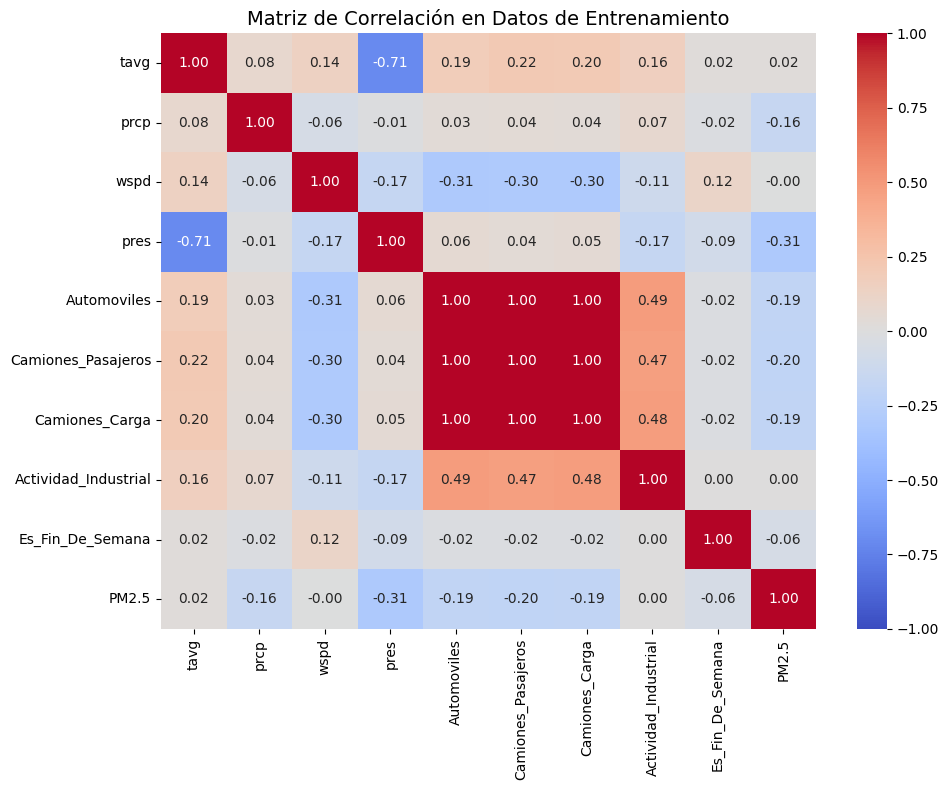


--- INICIANDO STEPWISE ---
Eliminando 'Camiones_Carga' (P-value: 0.9345)
Eliminando 'tavg' (P-value: 0.7273)
Eliminando 'wspd' (P-value: 0.1487)
Eliminando 'Actividad_Industrial' (P-value: 0.0727)

 ¡Selección Stepwise terminada!

--- RESUMEN DEL MODELO LINEAL (TRAIN) ---
Variables sobrevivientes: ['prcp', 'pres', 'Automoviles', 'Camiones_Pasajeros', 'Es_Fin_De_Semana']
                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     19.72
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           7.04e-17
Time:                        16:40:16   Log-Likelihood:                -949.43
No. Observations:                 292   AIC:                             1911.
Df Residuals:                     286   BIC:                             

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

df = pd.read_csv('Tabla_Analisis_Climatico.csv')
Y = df['PM2.5']
X = df.drop(columns=['Fecha', 'PM2.5'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=60)

print(f"Días totales en el año: {len(df)}")
print(f"Días usados para Entrenar (Train): {len(X_train)}")
print(f"Días usados para Examinar (Test): {len(X_test)}\n")

#ANÁLISIS DE OUTLIERS (EXCLUSIVO EN TRAIN)
print("--- RESUMEN DE VALORES ATÍPICOS (SOLO EN DATOS DE ENTRENAMIENTO) ---")
columnas_numericas = X_train.drop(columns=['Es_Fin_De_Semana']).columns

for col in columnas_numericas:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[col] < limite_inferior) | (X_train[col] > limite_superior)]
    if len(outliers) > 0:
        print(f" {col}: Encontró {len(outliers)} días anormales.")
    else:
        print(f" {col}: Limpio. Sin valores extremos.")

# 4. MATRIZ DE CORRELACIÓN (EXCLUSIVO EN TRAIN)
df_train_numerico = pd.concat([X_train, Y_train], axis=1).select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(df_train_numerico.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación en Datos de Entrenamiento", fontsize=14)
plt.tight_layout()
plt.show()

# 5. BACKWARD STEPWISE (EXCLUSIVO EN TRAIN)
def backward_stepwise(X_data, Y_data, significancia=0.05):
    variables_incluidas = list(X_data.columns)
    while True:
        X_con_constante = sm.add_constant(X_data[variables_incluidas])
        modelo = sm.OLS(Y_data, X_con_constante).fit()
        p_values = modelo.pvalues.drop('const')

        peor_p_value = p_values.max()
        peor_variable = p_values.idxmax()

        if peor_p_value > significancia:
            print(f"Eliminando '{peor_variable}' (P-value: {peor_p_value:.4f})")
            variables_incluidas.remove(peor_variable)
        else:
            print("\n ¡Selección Stepwise terminada!")
            break

    X_final = sm.add_constant(X_data[variables_incluidas])
    modelo_final = sm.OLS(Y_data, X_final).fit()
    return modelo_final, variables_incluidas

print("\n--- INICIANDO STEPWISE ---")
modelo_ganador, columnas_ganadoras = backward_stepwise(X_train, Y_train)

print("\n--- RESUMEN DEL MODELO LINEAL (TRAIN) ---")
print(f"Variables sobrevivientes: {columnas_ganadoras}")
print(modelo_ganador.summary())

**Modelos**
---
***
Este proyecto contrasta el desempeño de dos enfoques predictivos de distinta naturaleza. Inicialmente, se ajustó una Regresión Lineal Múltiple, un algoritmo ideal para medir relaciones directas en muestras limitadas. Como contraparte, se implementó un modelo basado en Árboles de Decisión para evaluar si algoritmos más complejos lograban capturar comportamientos no lineales en la atmósfera. Para validar cuál herramienta es la más conveniente, se utilizo la división de datos estricta del 80% para entrenamiento (Train) y 20% para prueba (Test) que se realizo durante la seleccion de caracteristicas. Cabe destacar que ambos modelos fueron evaluados exactamente sobre los mismos conjuntos de datos, garantizando así que la competencia predictiva y la validación de errores sean estadísticamente justas.

--- EVALUACIÓN FINAL EN DATOS DE PRUEBA (TEST) ---
R² en datos nuevos (Test): 0.3490
Error promedio (RMSE) en Test: 6.26 unidades de PM2.5



,PM2.5 Real,PM2.5 Predicho Lineal
151,15.12,18.86
306,18.92,18.47
14,27.29,17.90
329,17.53,18.75
40,24.04,24.52
112,28.22,26.05
83,20.00,23.95
203,24.68,18.46
12,8.67,19.79
326,32.44,21.45


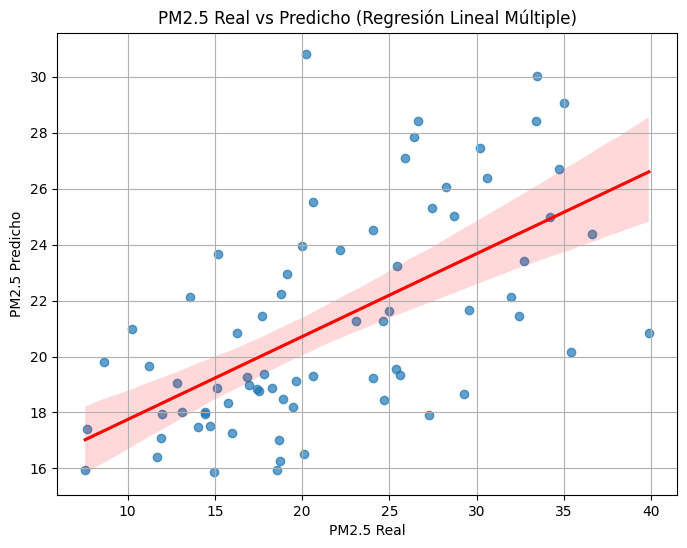

In [17]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

X_test_filtrado = X_test[columnas_ganadoras]
X_test_const = sm.add_constant(X_test_filtrado)

Y_pred_lineal = modelo_ganador.predict(X_test_const)

r2_lineal = r2_score(Y_test, Y_pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(Y_test, Y_pred_lineal))

print("--- EVALUACIÓN FINAL EN DATOS DE PRUEBA (TEST) ---")
print(f"R² en datos nuevos (Test): {r2_lineal:.4f}")
print(f"Error promedio (RMSE) en Test: {rmse_lineal:.2f} unidades de PM2.5\n")

resultados = pd.DataFrame({'PM2.5 Real': Y_test, 'PM2.5 Predicho Lineal': Y_pred_lineal.round(2)})
display(resultados.head(10))

plt.figure(figsize=(8, 6))
sns.regplot(x=Y_test, y=Y_pred_lineal, scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
plt.title('PM2.5 Real vs Predicho (Regresión Lineal Múltiple)')
plt.xlabel('PM2.5 Real')
plt.ylabel('PM2.5 Predicho')
plt.grid(True)
plt.show()

--- EVALUACIÓN DEL RANDOM FOREST (TEST) ---
R² en datos nuevos (Test): 0.0993
Error promedio (RMSE) en Test: 7.36 unidades de PM2.5

--- IMPORTANCIA DE CADA VARIABLE SEGÚN EL BOSQUE ---
pres                  0.5292
prcp                  0.1923
Camiones_Pasajeros    0.1168
Automoviles           0.1070
Es_Fin_De_Semana      0.0547
dtype: float64




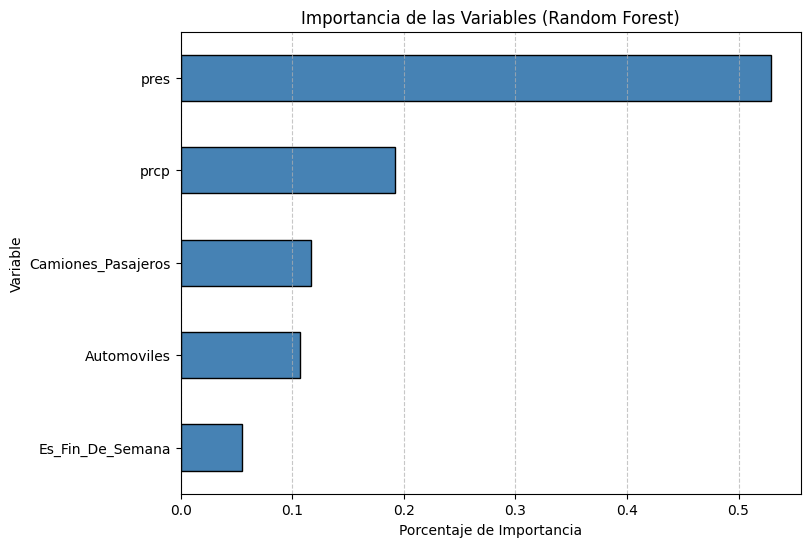

In [21]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

X_train_rf = X_train[columnas_ganadoras]
X_test_rf = X_test[columnas_ganadoras]

modelo_bosque = RandomForestRegressor(n_estimators=100, random_state=60)
modelo_bosque.fit(X_train_rf, Y_train)

Y_pred_bosque = modelo_bosque.predict(X_test_rf)

r2_bosque = r2_score(Y_test, Y_pred_bosque)
rmse_bosque = np.sqrt(mean_squared_error(Y_test, Y_pred_bosque))

print("--- EVALUACIÓN DEL RANDOM FOREST (TEST) ---")
print(f"R² en datos nuevos (Test): {r2_bosque:.4f}")
print(f"Error promedio (RMSE) en Test: {rmse_bosque:.2f} unidades de PM2.5\n")

importancias = pd.Series(modelo_bosque.feature_importances_, index=X_train_rf.columns)

print("--- IMPORTANCIA DE CADA VARIABLE SEGÚN EL BOSQUE ---")
print(importancias.sort_values(ascending=False).round(4))
print("\n")

plt.figure(figsize=(8, 6))
importancias.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Importancia de las Variables (Random Forest)')
plt.xlabel('Porcentaje de Importancia')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Interpretación de Coeficientes y Resultados/Regresion Lineal**
---
***
A partir de la Regresión Lineal Múltiple obtenida, el modelo logró explicar el 34.9% de la variabilidad en el comportamiento del PM2.5, todas siendo variables significativas gracias al stepwise. Analizando los coeficientes ($\beta$) de las variables que resultaron estadísticamente significativas ($p < 0.05$), se determinó el impacto directo de cada factor sobre la calidad del aire de la siguiente manera:

1. Automóviles: Como fuente antropogénica principal, presentan un impacto positivo en la polución; el modelo indica que por cada 10,000 automóviles adicionales en circulación, la concentración de PM2.5 aumenta en 1 unidad ($0.0001 \times 10,000$).
2. Fines de Semana (Es_Fin_De_Semana): Al ser una variable indicadora o dummy (0 para entre semana, 1 para fin de semana), su coeficiente demuestra que durante los sábados y domingos la concentración de PM2.5 se reduce en promedio por 1.74 unidades, reflejando claramente la pausa en la movilidad y la actividad urbana.
3. Presión atmosférica (pres): Presenta una relación inversa; por cada incremento de 1 milibar (o hPa) en la presión, la concentración de partículas se reduce en 0.57 unidades.
4. Precipitación (prcp): La precipitación tiene un efecto de "lavado" en la atmósfera, logrando que por cada 1 mm de lluvia, el contaminante baje en 0.30 unidades.
5. Camiones de Pasajeros: El modelo asignó una pendiente negativa a esta variable, indicando matemáticamente que por cada 1,000 camiones en circulación, el nivel reportado de PM2.5 disminuye en 3.5 unidades. Este fenómeno, aunque contraintuitivo, sugiere que una mayor afluencia de transporte urbano podría estar correlacionada de forma oculta con la disminución de otras actividades contaminantes no capturadas por el modelo.

**Desempeño Práctico del Modelo**

El modelo se equivoca en promedio por 6.26 micras de material particulado hacia arriba o hacia abajo. Considerando la escala en la que se mide esta variable, se concluye que es un margen de error moderadamente alto, lo cual reafirma de manera empírica que un sistema estrictamente lineal presenta límites notables para modelar la volatilidad de la atmósfera urbana.

**Interpretación de Coeficientes y Resultados/Random Forest**
---
***
Al evaluar el modelo de ensamble basado en árboles (Random Forest Regressor) sobre el conjunto de prueba, los resultados revelaron una caída pronunciada en su capacidad predictiva. El algoritmo obtuvo un R² de 0.0993, lo que indica que únicamente logró explicar el 9.93% de la variabilidad de los datos frente al 37.8% que logró el modelo lineal. Asimismo, la métrica de error (RMSE) subió a 7.36, lo que en la práctica significa que este modelo se equivoca, en promedio, por 7.36 unidades reales de material particulado al predecir la calidad del aire.

A diferencia de la regresión clásica, el Bosque Aleatorio no genera coeficientes proporcionales, sino que calcula la importancia relativa de cada variable en su proceso de toma de decisiones. El análisis de estas importancias con el nuevo subconjunto de datos arrojó descubrimientos reveladores:
1. Presión atmosférica (pres): Esta acaparó el 52.9% de la importancia. Esto indica que más de la mitad de los recortes matemáticos del algoritmo dependieron de este único factor físico, confirmando que la concentración de PM2.5 está fuertemente dictaminada por la meteorología.
2. Lluvia (prcp): La precipitación se consolidó como el segundo factor crítico, representando el 19.2% de las decisiones del bosque para evaluar los eventos de limpieza o "lavado" atmosférico.
3. Influencia vehicular y dinámica urbana: El algoritmo consideró que las fuentes antropogénicas tienen una importancia secundaria frente al clima. Los Camiones de Pasajeros (11.6%), los Automóviles (10.7%) y el efecto de los Fines de Semana (5.4%) sumaron en conjunto apenas un 27.7% del peso predictivo. Esto demuestra de manera empírica que, en un sistema no lineal con datos limitados, las condiciones climáticas eclipsan por completo la volatilidad de las emisiones urbanas diarias."

**Conclusion**
---
***
Este estudio concluye que las variables meteorológicas (presión, precipitación) y las dinámicas de movilidad urbana (parque vehicular y la pausa de los fines de semana) logran explicar el 34.9% de la variabilidad en las concentraciones de PM2.5 bajo un enfoque de Regresión Lineal Múltiple. Al contrastar esta métrica con un modelo no lineal complejo (Bosque Aleatorio) —el cual colapsó a una varianza explicada de apenas 9.93%—, el enfoque lineal demostró ser la herramienta más robusta, eficiente y adecuada para el volumen de observaciones actual ($n=365$). Esto evidencia empíricamente que los algoritmos avanzados de Machine Learning sufren un sobreajuste severo y pérdida de precisión cuando intentan modelar fenómenos con conjuntos de datos limitados.No obstante, el porcentaje de varianza explicada revela que, aunque los predictores resultaron altamente significativos, una ecuación estrictamente lineal presenta limitaciones matemáticas para modelar la volatilidad total de un sistema ambiental caótico. De cara al futuro, la integración de una base de datos mucho más extensa (escalando a registros horarios) y la adición de nuevas variables en algoritmos de ensamble no lineales, permitirá superar esta barrera, capturar comportamientos extremos en la atmósfera y pronosticar la calidad del aire con una precisión significativamente mayor.

**REFERENCIAS**
---
***
1. INSTITUTO NACIONAL DE ECOLOGÍA y CAMBIO CLIMÁTICO. (s. f.). https://sinaica.inecc.gob.mx/
2. De Estadística Y, I. N. (s. f.). Parque vehicular. https://www.inegi.org.mx/temas/vehiculos/#tabulados
3. El guardián del tiempo | Meteostat. (2025, 1 enero). https://meteostat.net/es/place/mx/san-pedro-garza-garcia?s=76394&t=2025-01-01/2025-12-31
4. De Estadística Y, I. N. (s. f.-a). Indicador Mensual de la Actividad Industrial por Entidad Federativa (IMAIEF). Año base 2018. https://www.inegi.org.mx/programas/aief/2018/
5. Gemini (versión de 2026) [Modelo de lenguaje grande]. https://gemini.google.com

In [24]:
!jupyter nbconvert --to html *.ipynb

[NbConvertApp] Converting notebook Modelado_Atmosférico_de_la_ZMM_Evaluación_de_Factores_Climáticos,_Vehiculares_e_Industriales_mediante_Regresión_Clásica_vs_Random_Forest.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 644933 bytes to Modelado_Atmosférico_de_la_ZMM_Evaluación_de_Factores_Climáticos,_Vehiculares_e_Industriales_mediante_Regresión_Clásica_vs_Random_Forest.html
